# 03. Documento de trabajo para verificar la hipótesis #03

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

clean_data_df = pd.read_csv("..\\data\\CLEAN_Students_Social_Media_Addiction.csv")
clean_data_df.index = clean_data_df["Student_ID"]

clean_data_df = clean_data_df.drop(columns=["Unnamed: 0"]) # Eliminamos la columna que había quedado guardada como índice

clean_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 503 entries, 3 to 705
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    503 non-null    int64  
 1   Age                           503 non-null    int64  
 2   Gender                        503 non-null    object 
 3   Academic_Level                503 non-null    object 
 4   Country                       503 non-null    object 
 5   Avg_Daily_Usage_Hours         503 non-null    float64
 6   Most_Used_Platform            503 non-null    object 
 7   Affects_Academic_Performance  503 non-null    object 
 8   Sleep_Hours_Per_Night         503 non-null    float64
 9   Mental_Health_Score           503 non-null    int64  
 10  Relationship_Status           503 non-null    object 
 11  Conflicts_Over_Social_Media   503 non-null    int64  
 12  Addicted_Score                503 non-null    int64  
dtypes: float64

### 3.3 Hipótesis: Los usuarios que mayoritariamente usan Instagram y Tik Tok, perciben que el uso de las redes sociales afecta negativamente a su rendimiento académico que aquellos encuestados con preferencia por otras redes sociales

In [ ]:
# Agrupamos por red social y afectación auto-percibida
percentage_of_students_reporting_social_media_affects_performance = clean_data_df.groupby(["Most_Used_Platform", "Affects_Academic_Performance"])[["Affects_Academic_Performance"]].count()
percentage_of_students_reporting_social_media_affects_performance.columns = ["Affects_Academic_Performance_Count"]
percentage_of_students_reporting_social_media_affects_performance

Affects_Academic_Performance_Count
Most_Used_Platform Affects_Academic_Performance                                    
Facebook           No                                                            72
                   Yes                                                           30
Instagram          No                                                            77
                   Yes                                                          125
LinkedIn           No                                                            21
Snapchat           No                                                             1
                   Yes                                                           12
TikTok             No                                                             6
                   Yes                                                          122
Twitter            No                                                            18
                   Yes                                                           11
YouTube            No                                                             5
                   Yes                                                            3

In [9]:
## Debemos calcular el porcentaje de respuestas de cada tipo, para cada red social

# Creamos un dataframe con el conteo total:
most_used_platform_count = clean_data_df.groupby("Most_Used_Platform")["Student_ID"].count().reset_index()
most_used_platform_count.columns = ["Most_Used_Platform", "Total_Platform_Count"]

# Mergeamos el dataframe anterior con el conteo total
percentage_of_students_reporting_social_media_affects_performance_with_totals = pd.merge(percentage_of_students_reporting_social_media_affects_performance.reset_index(), most_used_platform_count, how="left", on="Most_Used_Platform")
percentage_of_students_reporting_social_media_affects_performance_with_totals = percentage_of_students_reporting_social_media_affects_performance_with_totals.set_index(['Most_Used_Platform', 'Affects_Academic_Performance'])

percentage_of_students_reporting_social_media_affects_performance_with_totals

Affects_Academic_Performance_Count  \
Most_Used_Platform Affects_Academic_Performance                                       
Facebook           No                                                            72   
                   Yes                                                           30   
Instagram          No                                                            77   
                   Yes                                                          125   
LinkedIn           No                                                            21   
Snapchat           No                                                             1   
                   Yes                                                           12   
TikTok             No                                                             6   
                   Yes                                                          122   
Twitter            No                                                            18   
                   Yes                                                           11   
YouTube            No                                                             5   
                   Yes                                                            3   

                                                 Total_Platform_Count  
Most_Used_Platform Affects_Academic_Performance                        
Facebook           No                                             102  
                   Yes                                            102  
Instagram          No                                             202  
                   Yes                                            202  
LinkedIn           No                                              21  
Snapchat           No                                              13  
                   Yes                                             13  
TikTok             No                                             128  
                   Yes                                            128  
Twitter            No                                              29  
                   Yes                                             29  
YouTube            No                                               8  
                   Yes                                              8

In [10]:
# Calculamos el porcentaje
percentage_of_students_reporting_social_media_affects_performance_with_totals["Affects_Academic_Performance_%"] = percentage_of_students_reporting_social_media_affects_performance_with_totals["Affects_Academic_Performance_Count"] /  percentage_of_students_reporting_social_media_affects_performance_with_totals["Total_Platform_Count"] * 100

# Ordenamos primero los Yes, y luego los que más afectan a los estudios en porcentaje

percentage_of_students_reporting_social_media_affects_performance_with_totals_and_ordered = percentage_of_students_reporting_social_media_affects_performance_with_totals.sort_values(
    by=[
        'Affects_Academic_Performance', # This targets the column/level named 'Product'
        'Affects_Academic_Performance_%'
    ],
    ascending=[
        False,   # Sort Affects_Academic_Performance descending (Yes then No)
        False   # Sort Affects_Academic_Performance_ (highest to lowest)
    ]
)

# restablecemos el índice para poder mostrarlo más fácil como gráfico
percentage_of_students_reporting_social_media_affects_performance_with_totals_and_ordered = percentage_of_students_reporting_social_media_affects_performance_with_totals_and_ordered.reset_index()
percentage_of_students_reporting_social_media_affects_performance_with_totals_and_ordered

,Most_Used_Platform,Affects_Academic_Performance,Affects_Academic_Performance_Count,Total_Platform_Count,Affects_Academic_Performance_%
0,TikTok,Yes,122,128,95.312500
1,Snapchat,Yes,12,13,92.307692
2,Instagram,Yes,125,202,61.881188
3,Twitter,Yes,11,29,37.931034
4,YouTube,Yes,3,8,37.500000
5,Facebook,Yes,30,102,29.411765
6,LinkedIn,No,21,21,100.000000
7,Facebook,No,72,102,70.588235
8,YouTube,No,5,8,62.500000
9,Twitter,No,18,29,62.068966


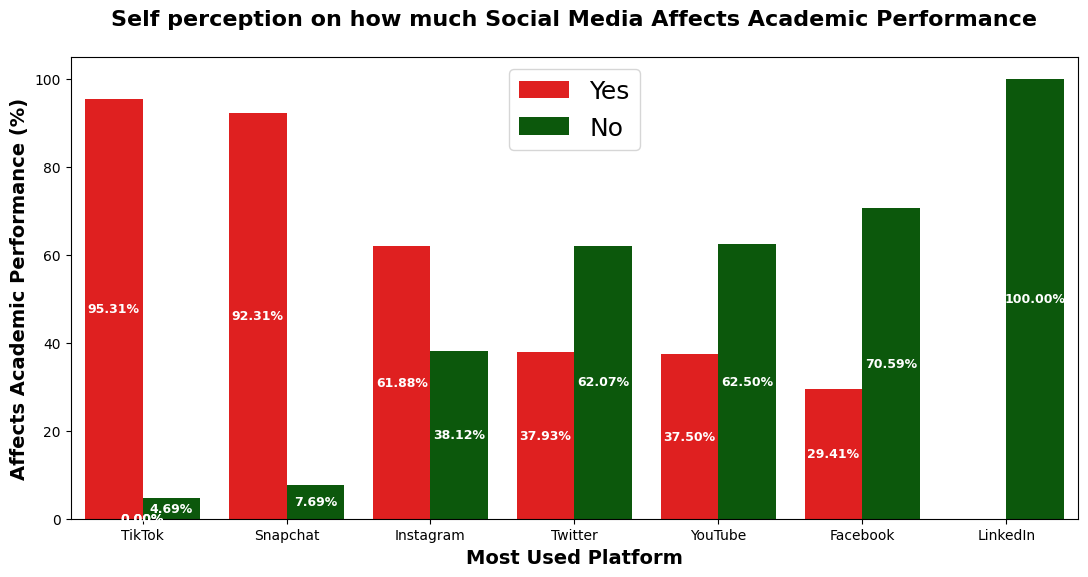

In [11]:
# Extraemos el gráfico a mostrar

plt.figure(figsize=(13, 6))

fig = sns.barplot(
    data=percentage_of_students_reporting_social_media_affects_performance_with_totals_and_ordered, 
    x=percentage_of_students_reporting_social_media_affects_performance_with_totals_and_ordered["Most_Used_Platform"],
    hue=percentage_of_students_reporting_social_media_affects_performance_with_totals_and_ordered["Affects_Academic_Performance"],
    y=percentage_of_students_reporting_social_media_affects_performance_with_totals_and_ordered["Affects_Academic_Performance_%"],
    palette=["#FF0000","#006400"])

for p in fig.patches:
    # Get the height of the bar (the value on the y-axis)
    height = p.get_height()

    # 2d. Lookup the specific Label_Text from the DataFrame
    final_label = f'{height:.2f}%' # Format the text (e.g., to 2 decimal places)
    # Determine where to place the label:
    # x-coordinate: p.get_x() + p.get_width() / 2 (Center of the bar)
    # y-coordinate: height / 2 (Halfway up the bar, inside)

    # Add the text annotation
    fig.text(
        x=p.get_x() + p.get_width() / 2.,  # Center horizontally
        y=height * 0.5,                   # Place vertically at 50% height
        s=final_label,                     # The text to display
        ha='center',                      # Horizontal alignment
        va='center',                      # Vertical alignment
        color='white',                    # Use a contrasting color
        fontsize=9,
        fontweight='bold'
    )

fig.set_title("Self perception on how much Social Media Affects Academic Performance" + "\n", fontweight='bold', fontsize=16);
fig.set_xlabel("Most Used Platform", fontweight='bold', fontsize=14);
fig.set_ylabel("Affects Academic Performance (%)", fontweight='bold', fontsize=14)
plt.legend(fontsize=18)
plt.show();

#### 🤷‍♂️ Tan sólo podemos validar parcialmente la hipótesis 3 

Esperábamos ver Tik Tok e Instagram en el Top 2 de redes que podríamos vincular con un mayor impacto negativo en el rendimiento académico, sin embargo, tan sólo vemos a Tik Tok en este Top 2, siendo Snapchat la que nos ha sorprendido como aquella donde observamos en el segundo puesto.

Cabe destacar que Tik Tok y Snapchat están muy cerca entre sí, y que la diferencia es muy grande respecto al resto de plataformas